# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_mae, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_mae"] = pd.to_numeric(df["val_mae"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 63
Columns: ['commit', 'val_mae', 'memory_gb', 'status', 'description']


,commit,val_mae,memory_gb,status,description
0,2929fbd,5.5799,3.0,KEEP,"baseline: pretrained T5Chem, AdamW lr=5e-4, bs..."
1,a9504da,6.8152,3.0,DISCARD,"lower LR 5e-4->1e-4, warmup 5%"
2,71de69e,5.4501,2.6,KEEP,dropout 0.1->0.0
3,cacbb18,5.8601,9.6,DISCARD,batch size 32->128 (too few steps)
4,78ecdca,5.6226,2.6,DISCARD,"LR 1e-3, warmup 5%, warmdown 50%"
5,f790bd8,5.7222,2.4,DISCARD,encoder-only mean pooling (skip decoder)
6,670ca11,6.1450,2.6,DISCARD,deeper regression head 256->256->2 GELU
7,0069ecd,6.6096,2.1,DISCARD,freeze encoder blocks
8,4e5f249,5.8018,2.6,DISCARD,Adam beta2 0.999->0.98
9,f0dd97e,5.9688,2.6,DISCARD,differential LR encoder 10x lower


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    56
KEEP        6
SKIP        1

Keep rate: 6/62 = 9.7%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    mae = row["val_mae"]
    desc = row["description"]
    print(f"  #{i:3d}  mae={mae:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (6 total):

  #  0  mae=5.579900  mem=3.0GB  baseline: pretrained T5Chem, AdamW lr=5e-4, bs=32, dropout=0.1
  #  2  mae=5.450100  mem=2.6GB  dropout 0.1->0.0
  # 20  mae=5.426000  mem=1.4GB  T=300 + dropout=0.05 (faster steps + light reg)
  # 22  mae=5.347200  mem=1.4GB  T=300 dropout 0.08
  # 61  mae=5.291900  mem=1.4GB  L1 loss on prediction (direct MAE optimization vs KL divergence)
  # 62  mae=5.005500  mem=1.4GB  L1 + dropout 0.08->0.05


## Val mae Over Time

Track how the best (kept) val_mae evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

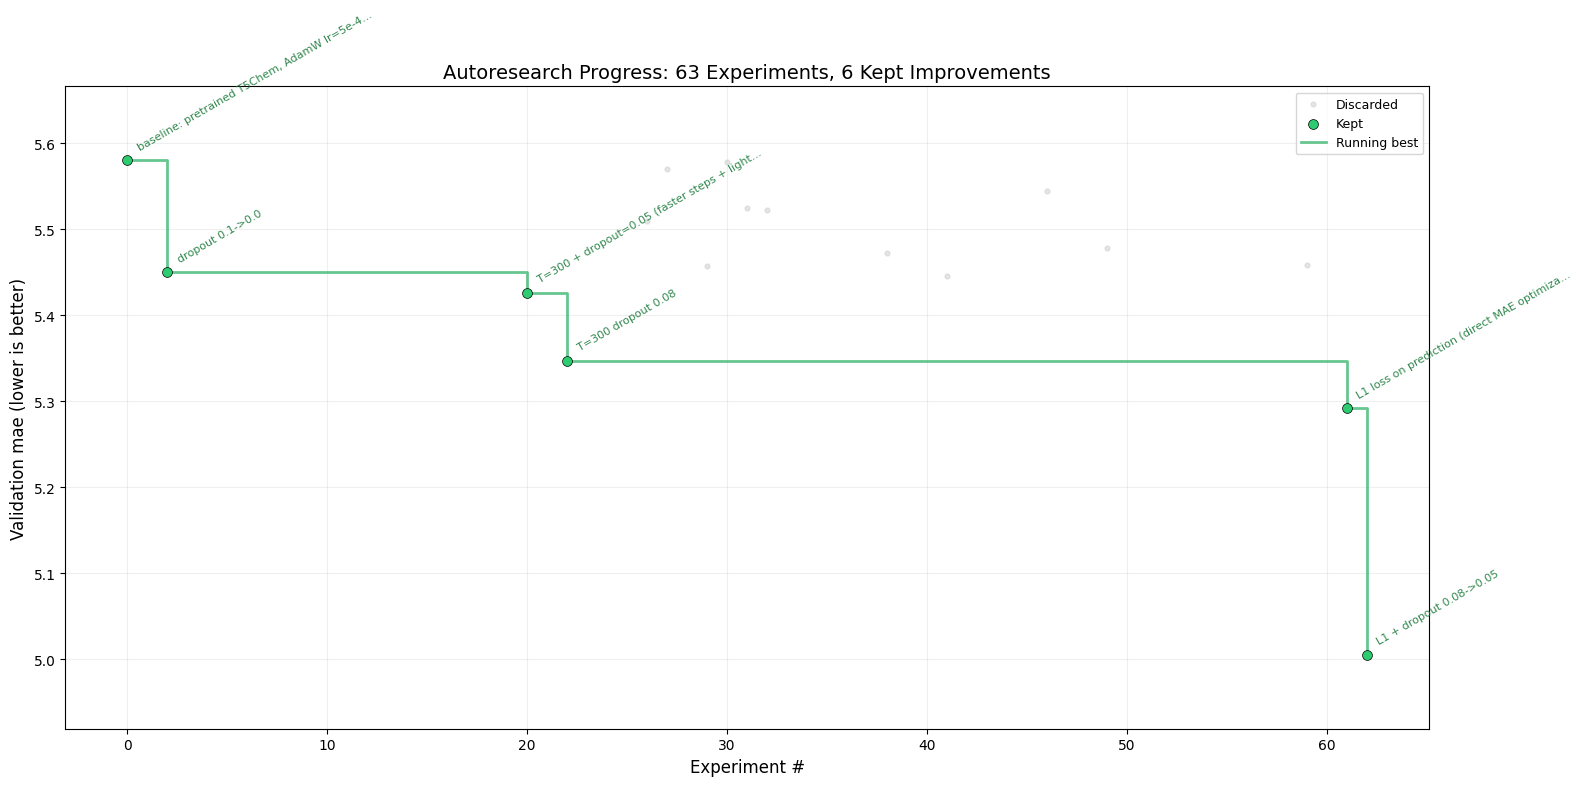

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_mae = valid.loc[0, "val_mae"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_mae"] <= baseline_mae + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_mae"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_mae"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_mae = valid.loc[kept_mask, "val_mae"]
running_min = kept_mae.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, mae in zip(kept_idx, kept_mae):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, mae),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation mae (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_mae = kept_mae.min()
margin = (baseline_mae - best_mae) * 0.15
ax.set_ylim(best_mae - margin, baseline_mae + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_mae = df.iloc[0]["val_mae"]
best_mae = kept["val_mae"].min()
best_row = kept.loc[kept["val_mae"].idxmin()]

print(f"Baseline val_mae:  {baseline_mae:.6f}")
print(f"Best val_mae:      {best_mae:.6f}")
print(f"Total improvement: {baseline_mae - best_mae:.6f} ({(baseline_mae - best_mae) / baseline_mae * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: mae={row['val_mae']:.6f}  {desc}")

Baseline val_mae:  5.579900
Best val_mae:      5.005500
Total improvement: 0.574400 (10.29%)
Best experiment:   L1 + dropout 0.08->0.05

Cumulative effort per improvement:
  Experiment #  0: mae=5.579900  baseline: pretrained T5Chem, AdamW lr=5e-4, bs=32, dropout=0.1
  Experiment #  2: mae=5.450100  dropout 0.1->0.0
  Experiment # 20: mae=5.426000  T=300 + dropout=0.05 (faster steps + light reg)
  Experiment # 22: mae=5.347200  T=300 dropout 0.08
  Experiment # 61: mae=5.291900  L1 loss on prediction (direct MAE optimization vs KL divergence)
  Experiment # 62: mae=5.005500  L1 + dropout 0.08->0.05


## Top Hits (Kept Experiments by Improvement)

In [ ]:
# Each kept experiment's delta is measured vs the previous kept experiment's mae
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_mae"] = kept["val_mae"].shift(1)
kept["delta"] = kept["prev_mae"] - kept["val_mae"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'mae':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_mae']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")